# XOR Neural Network Visualization

This notebook demonstrates training a neural network on the XOR problem and visualizing the decision boundary.

In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('..')

from ml_core.losses import BinaryCrossentropy as BCE_Loss
from ml_core import Network as Neural_Network
from ml_core.layers import DenseLayer as Dense_Layer
from ml_core.activations import Sigmoid as Sigmoid_Activation
from ml_core.activations import ReLU as ReLU_Activation

## XOR Dataset

The XOR (exclusive OR) problem is a classic non-linear classification problem that cannot be solved by a single-layer perceptron.

In [2]:
# Define XOR inputs and expected outputs
inputs = [
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
]
labels = [
    [0],
    [1],
    [1],
    [0]
]

# Convert labels to numpy array for calculations
labels = np.array(labels)

## Training the Neural Network

We'll create a neural network with:
- 2 input neurons (for the 2 XOR inputs)
- 4 neurons in the hidden layer
- 1 output neuron (for binary classification)

In [3]:
# Training parameters
num_epochs = 500
learning_rate = 0.1

# Initialize the loss function
bce_loss = BCE_Loss()

# Initialize the network
# 2 inputs, 4 hidden, 1 output
neural_network = Neural_Network([
    Dense_Layer(input_size=2, output_size=4, initializer='he'),
    ReLU_Activation(),
    Dense_Layer(input_size=4, output_size=1, initializer='xavier'),
    Sigmoid_Activation(),
])

# Lists to track progress
loss_history = []

In [4]:
try:
    # Training loop with progress tracking
    for epoch in range(num_epochs):
        # Forward pass
        predictions = neural_network.forward(inputs=inputs)
        loss = bce_loss.forward(predictions=predictions, labels=labels)
        gradient = bce_loss.backward()
        
        # Backward pass
        neural_network.backward(loss_gradient=gradient, learning_rate=learning_rate)
        
        # Record loss every 500 epochs
        if epoch % 10 == 0 or epoch == num_epochs - 1:
            loss_history.append(loss)
            if epoch % 100 == 0:
                print(f"Epoch {epoch}/{num_epochs}, Loss: {loss:.6f}")
except Exception as e:
    print("Training interrupted or error occurred:", e)
finally:
    print("Saving model or logs...")

Epoch 0/500, Loss: 0.841859
Epoch 100/500, Loss: 0.527453
Epoch 200/500, Loss: 0.456547
Epoch 300/500, Loss: 0.423760
Epoch 400/500, Loss: 0.397967
Saving model or logs...


## Visualizing Training Progress

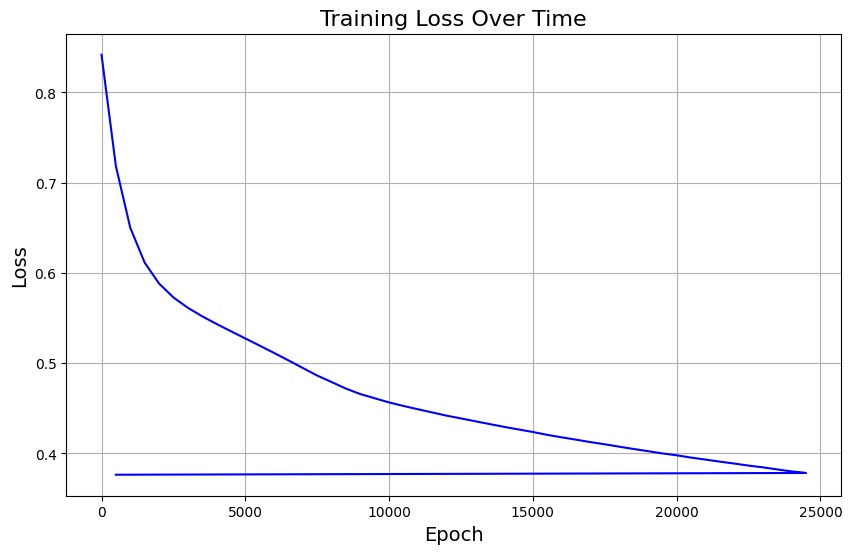

In [5]:
# Plot loss over time
plt.figure(figsize=(10, 6))
epochs_tracked = [i*num_epochs for i in range(len(loss_history)-1)] + [num_epochs-1]
plt.plot(epochs_tracked, loss_history, 'b-')
plt.title('Training Loss Over Time', fontsize=16)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.grid(True)
plt.show()

## Evaluating the Model

In [6]:
# Make predictions
final_predictions = neural_network.forward(inputs)
rounded_predictions = np.round(final_predictions)

# Display predictions vs actual
for i in range(len(inputs)):
    print(f"Input: {inputs[i]} | Actual: {labels[i][0]} | Predicted: {final_predictions[i][0]:.4f} | Rounded: {rounded_predictions[i][0]}")

Input: [0, 0] | Actual: 0 | Predicted: 0.1259 | Rounded: 0.0
Input: [0, 1] | Actual: 1 | Predicted: 0.8938 | Rounded: 1.0
Input: [1, 0] | Actual: 1 | Predicted: 0.4729 | Rounded: 0.0
Input: [1, 1] | Actual: 0 | Predicted: 0.3987 | Rounded: 0.0


## Decision Boundary Visualization

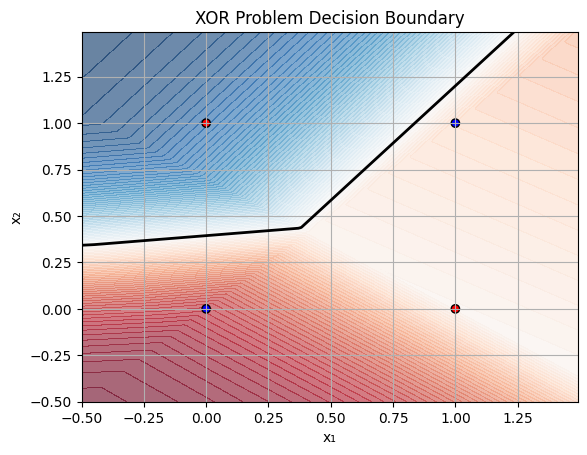

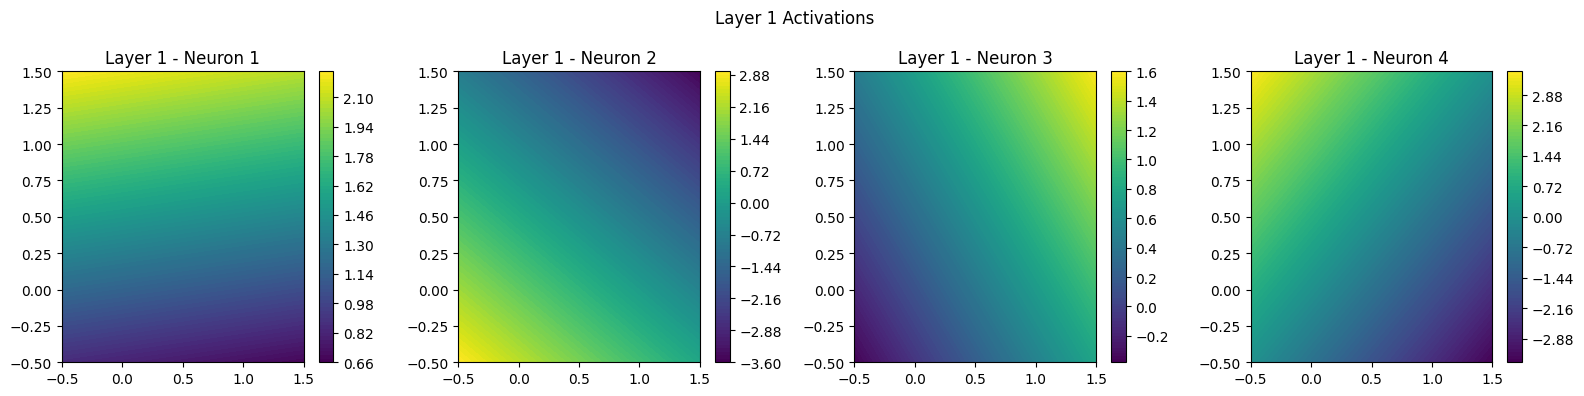

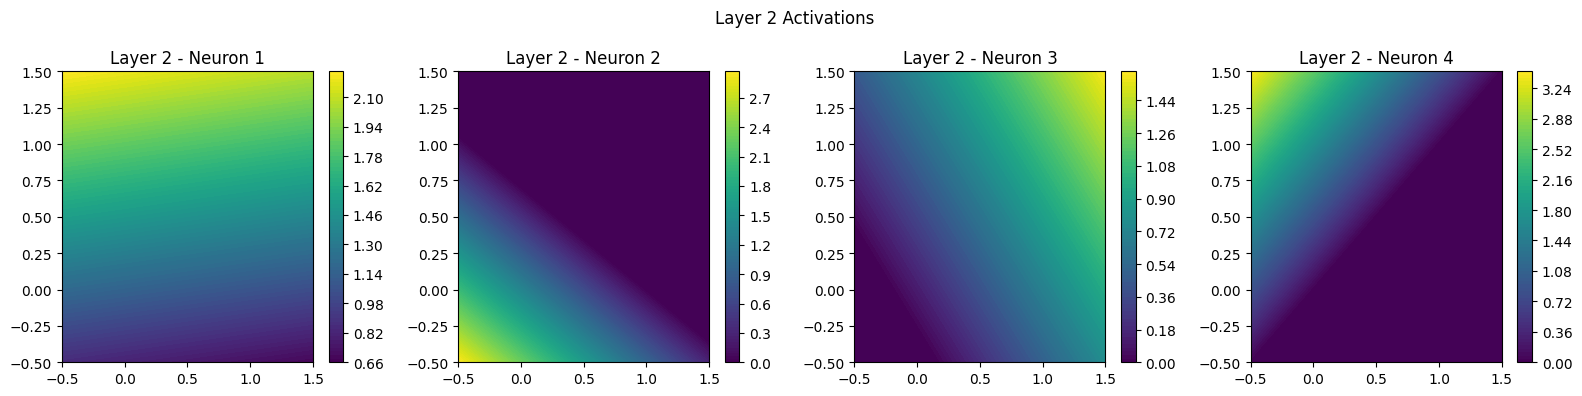

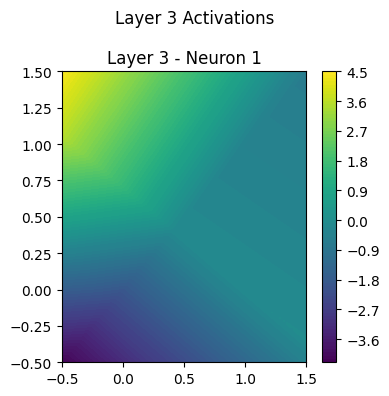

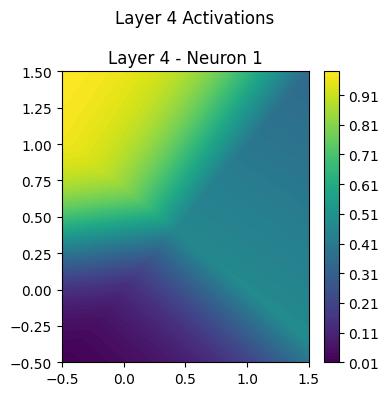

Layer 1 Neuron 1 weights: [-0.08438658 -1.3426974   0.57198964 -1.70942374]
Layer 1 Neuron 2 weights: [ 0.69540102 -1.90135956  0.40559239  1.70674244]


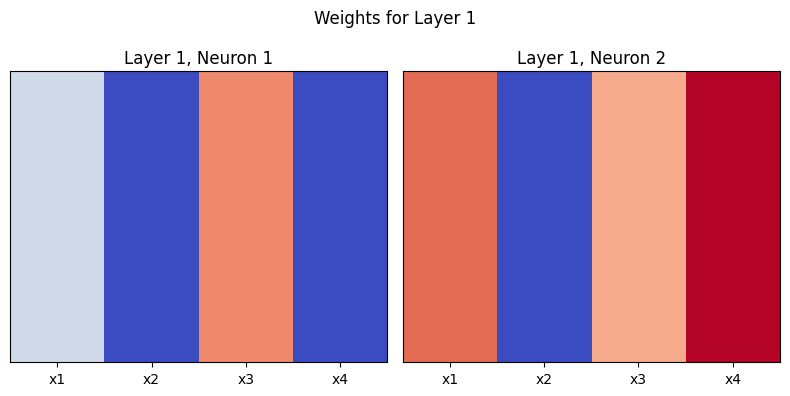

Layer 3 Neuron 1 weights: [-0.23511148]
Layer 3 Neuron 2 weights: [-1.50074146]
Layer 3 Neuron 3 weights: [-0.3415551]
Layer 3 Neuron 4 weights: [1.38562864]


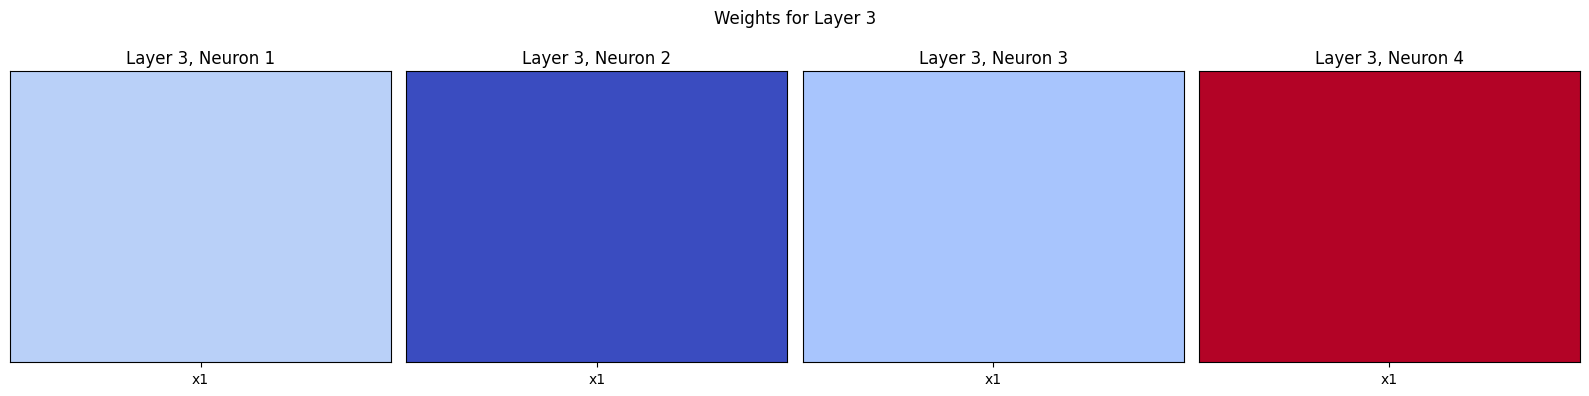

In [7]:
# Visualize the decision boundary
from milestone_1_1.visualize import plot_decision_boundary
from milestone_1_1.visualize import plot_all_layer_activations
from milestone_1_1.visualize import plot_layer_weights

plot_decision_boundary(model=neural_network, X=inputs, y=labels, title="XOR Problem Decision Boundary")
plot_all_layer_activations(model=neural_network)
plot_layer_weights(neural_network)